# 多元函数偏导与梯度

学习目标：用偏导、全微分和单位方向导数描述多元函数的局部变化，核对梯度与等高线的关系，并判断局部线性近似所需的条件。

前置知识：单变量导数、向量、内积。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11；主线使用二维实值函数，向量与梯度采用列向量约定。

环境准备：见 [README.md](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 两个输入共同决定一个输出

考虑无单位函数

$$f(x,y)=x^2+2xy+3y^2,\qquad (x,y)\in\mathbb R^2.$$

它把一个有序数对映射成一个实数。在点 $(1,0.5)$，函数值为 2.75。只改 x、只改 y 或同时改两个量，会得到不同变化。

一般的多元实值函数写为 $f:D\subseteq\mathbb R^n\to\mathbb R$，n 为正整数，D 为定义域。定义域中的点用列向量 $\mathbf{x}=(x_1,\ldots,x_n)^T$ 表示；二维时写成 $(x,y)^T$。本章在定义域内部讨论导数，使足够小的正负增量都可取。

图像 $z=f(x,y)$ 是三维中的曲面；等高线 $f(x,y)=c$ 则把同一个函数值 c 的位置画在二维输入平面。下面先从几个点的值开始。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 11}
)


def f(x, y):
    """计算教学用二元多项式，输入也可以是同形数组。"""
    return x**2 + 2 * x * y + 3 * y**2


p = np.array([1.0, 0.5])
print("基准函数值：", f(*p))  # 2.75。
for delta in [np.array([0.1, 0.0]), np.array([0.0, 0.1]), np.array([0.1, 0.1])]:
    print("增量：", delta, "；函数变化：", f(*(p + delta)) - f(*p))  # 仅动 x、仅动 y、同时改变二者，函数变化分别约为 0.31、0.53、0.86。
# 三种变化分别接近 0.31、0.53、0.86；同时变化还会受到交叉项影响。

基准函数值： 2.75
增量： [0.1 0. ] ；函数变化： 0.3100000000000005
增量： [0.  0.1] ；函数变化： 0.5300000000000002
增量： [0.1 0.1] ；函数变化： 0.8600000000000003


## 2 偏导数固定其他输入，只改变一个变量

设 $p=(a,b)^T$ 为定义域内部的一点，h 为趋于零的非零实数。关于 x 的偏导数（partial derivative）定义为

$$f_x(a,b)=\frac{\partial f}{\partial x}(a,b)
=\lim_{h\to0}\frac{f(a+h,b)-f(a,b)}{h},$$

关于 y 的偏导数则固定 x：

$$f_y(a,b)=\frac{\partial f}{\partial y}(a,b)
=\lim_{h\to0}\frac{f(a,b+h)-f(a,b)}{h}.$$

求偏导时，未求导的变量当作常数。因此本例有

$$f_x(x,y)=2x+2y,\qquad f_y(x,y)=2x+6y.$$

在 $p=(1,0.5)^T$，两个偏导分别为 3、5。前向差商是把极限中的 h 暂时取成小数的近似；本例展开后分别为 $3+h$ 和 $5+3h$，可以直接预测步长变化的结果。

In [2]:
for h in [1e-1, 1e-2, 1e-3, 1e-4]:
    dx_estimate = (f(p[0] + h, p[1]) - f(*p)) / h
    dy_estimate = (f(p[0], p[1] + h) - f(*p)) / h
    print(f"h={h:.0e}，x 偏导近似={dx_estimate:.6f}，y 偏导近似={dy_estimate:.6f}")  # 两列差商逐步靠近 3、5；最后一组为 3.0001、5.0003。
# 逐渐接近 3 和 5；有限个差商只能核对公式，不能代替极限证明。

h=1e-01，x 偏导近似=3.100000，y 偏导近似=5.300000
h=1e-02，x 偏导近似=3.010000，y 偏导近似=5.030000
h=1e-03，x 偏导近似=3.001000，y 偏导近似=5.003000
h=1e-04，x 偏导近似=3.000100，y 偏导近似=5.000300


如果 x、y 都跟着同一个参数 t 改变，就不再是“固定另一变量”的偏导。例如沿直线 $x=y=t$，本例变为单变量函数 $f(t,t)=6t^2$，所以在 $t=1$ 时对 t 的导数是 12；而 $f_x(1,1)=4$。

这两个数回答的问题不同。前者沿一条路径同时改变两个输入，后者只改变 x。

In [3]:
t = 1.0
h = 1e-5
path_derivative = (f(t + h, t + h) - f(t - h, t - h)) / (2 * h)
partial_x = 2 * t + 2 * t
print("沿 x=y=t 的变化率：", path_derivative)  # 接近 12。
print("固定 y 时的 x 偏导：", partial_x)  # 4。

沿 x=y=t 的变化率： 11.999999999989795
固定 y 时的 x 偏导： 4.0


## 3 梯度把各偏导排成列向量

如果各偏导存在，梯度（gradient）是由它们组成的向量。本章固定采用列布局：

$$\nabla f(\mathbf{x})=
\begin{pmatrix}
\partial f/\partial x_1\\\vdots\\\partial f/\partial x_n
\end{pmatrix}\in\mathbb R^{n\times1}.$$

二维例子中，$\nabla f(x,y)=(2x+2y,\;2x+6y)^T$。梯度的分量顺序必须与输入分量一致。

NumPy 中用形状为 (2,) 的一维数组保存这个数学列向量，点积写成 gradient @ delta。若要显式保留列形状，使用形状 (2, 1) 的数组；一维数组的 .T 不会自动变成二维列。

此时“各偏导组成梯度”只是定义。要把它用作所有方向的局部变化率，还需要下面的可微条件。

In [4]:
def gradient_f(x, y):
    """按 x、y 的顺序返回偏导。"""
    return np.array([2 * x + 2 * y, 2 * x + 6 * y])


gradient = gradient_f(*p)
gradient_column = gradient.reshape(2, 1)
print("梯度数组：", gradient, "；形状：", gradient.shape)  # 预期为 [3. 5.] ；形状： (2,)。
print("显式列向量：\n", gradient_column, "；形状：", gradient_column.shape)  # 预期为 [[3.] [5.]] ；形状： (2, 1)。
# 数学梯度是 (3, 5)^T；数组布局不会改变它的分量含义。

梯度数组： [3. 5.] ；形状： (2,)
显式列向量：
 [[3.]
 [5.]] ；形状： (2, 1)


用中心差分可以分别核对每个分量：关于 x 的近似是 $[f(a+h,b)-f(a-h,b)]/(2h)$，关于 y 同理。对本例的二次多项式，展开后 h 的一次误差项相消；实际计算仍有浮点误差。

下面选 $h=10^{-4}$，输入与导数都在 1 附近到个位数量级，以 $10^{-8}$ 的绝对误差作为本例核对标准。步长过小时可能损失精度，不能把“h 越小”当作始终更准的规则。

In [5]:
h = 1e-4
# 每次只扰动一个坐标，另一个保持不变；两项按 x、y 顺序排成梯度。
numerical_gradient = np.array(
    [
        (f(p[0] + h, p[1]) - f(p[0] - h, p[1])) / (2 * h),
        (f(p[0], p[1] + h) - f(p[0], p[1] - h)) / (2 * h),
    ]
)
print("中心差分梯度：", numerical_gradient)  # 预期为 [3. 5.]。
print("最大绝对误差：", np.max(np.abs(numerical_gradient - gradient)))  # 本次数值约为 5.5e-13。
print("本例容差内一致：", np.allclose(numerical_gradient, gradient, atol=1e-8, rtol=0))  # 预期为 True。

中心差分梯度： [3. 5.]
最大绝对误差： 5.506706202140776e-13
本例容差内一致： True


## 4 可微要求一个线性式同时适配所有小增量

令 $\mathbf{h}\in\mathbb R^n$ 为输入增量。函数在内部点 p 可微，指存在一个关于 $\mathbf{h}$ 的线性映射 L，使

$$f(p+\mathbf{h})-f(p)=L(\mathbf{h})+r(\mathbf{h}),\qquad
\lim_{\mathbf{h}\to0,\,\mathbf{h}\ne0}\frac{|r(\mathbf{h})|}{\|\mathbf{h}\|_2}=0.$$

这里 $r(\mathbf{h})$ 是余项，$\|\mathbf{h}\|_2$ 是增量的欧氏长度。关键是余项相对增量还要更小，而且条件针对所有趋近方式；只沿坐标轴检查不够。

若函数可微，偏导存在，唯一的线性部分为

$$L(\mathbf{h})=\nabla f(p)^T\mathbf{h}.$$

这个线性映射称为全微分（total differential）。二维记为 $df=f_x(p)\,dx+f_y(p)\,dy$，其中 $dx=h_1,dy=h_2$。df 给出一阶变化，实际变化 $\Delta f=f(p+\mathbf{h})-f(p)$ 还包含余项，二者通常不精确相等。

In [6]:
delta = np.array([0.02, -0.01])
df = gradient @ delta
actual_change = f(*(p + delta)) - f(*p)
print("全微分给出的变化：", df)  # 0.01。
print("实际变化：", actual_change)  # 0.0103。
print("余项：", actual_change - df)  # 0.0003。

全微分给出的变化： 0.009999999999999995
实际变化： 0.010299999999999976
余项： 0.00029999999999998084


### 4.1 用余项界证明本例可微

对二次多项式在任意点 p 展开，线性项正是梯度点积，剩余部分为

$$r(\mathbf{h})=h_1^2+2h_1h_2+3h_2^2.$$

利用 $2|h_1h_2|\le h_1^2+h_2^2$，有

$$|r(\mathbf{h})|\le2h_1^2+4h_2^2\le4\|\mathbf{h}\|_2^2.$$

因此 $|r(\mathbf{h})|/\|\mathbf{h}\|_2\le4\|\mathbf{h}\|_2\to0$，这对所有小增量成立。下面的三条路径只是展示这条界的数值表现，证明来自上面的不等式。

常用的充分条件是：各一阶偏导在 p 的某个邻域内存在，并在 p 连续，则函数在 p 可微。连续偏导是充分条件，不能反过来把它当作可微的定义。

In [7]:
for direction in [np.array([1.0, 0.0]), np.array([0.0, 1.0]), np.array([1.0, -2.0])]:
    print("路径向量：", direction)  # 三条路径方向依次为 [1, 0]、[0, 1]、[1, -2]。
    for t in [0.1, 0.01, 0.001]:
        delta = t * direction
        remainder = delta[0] ** 2 + 2 * delta[0] * delta[1] + 3 * delta[1] ** 2
        # 每条路径的 t 缩小十倍，归一化余项也缩小十倍；最后分别约 0.001、0.003、0.004025。
        print(f"  t={t:g}，归一化余项={abs(remainder) / np.linalg.norm(delta):.6g}")
# 每条路径的比值都随 t 缩小；它们不替代对所有路径的余项界。

路径向量： [1. 0.]
  t=0.1，归一化余项=0.1
  t=0.01，归一化余项=0.01
  t=0.001，归一化余项=0.001
路径向量： [0. 1.]
  t=0.1，归一化余项=0.3
  t=0.01，归一化余项=0.03
  t=0.001，归一化余项=0.003
路径向量： [ 1. -2.]
  t=0.1，归一化余项=0.402492
  t=0.01，归一化余项=0.0402492
  t=0.001，归一化余项=0.00402492


### 4.2 局部线性近似与切平面

在 $p=(1,0.5)^T$，局部线性近似为

$$f(x,y)\approx \ell(x,y)=2.75+3(x-1)+5(y-0.5).$$

严格说，$\ell$ 含常数项，是仿射函数；“线性近似”强调增量部分是线性的。曲面 $z=f(x,y)$ 在该点的切平面就是 $z=\ell(x,y)$。

下面固定 y=0.5，比较 $f(1+t,0.5)$ 与 $2.75+3t$。t 为 x 的增量，余项恰好是 $t^2$。两张图使用不同的 t 区间，观察近似如何在基准点附近贴合，而不是把切平面用于任意远处。此图各量无单位。

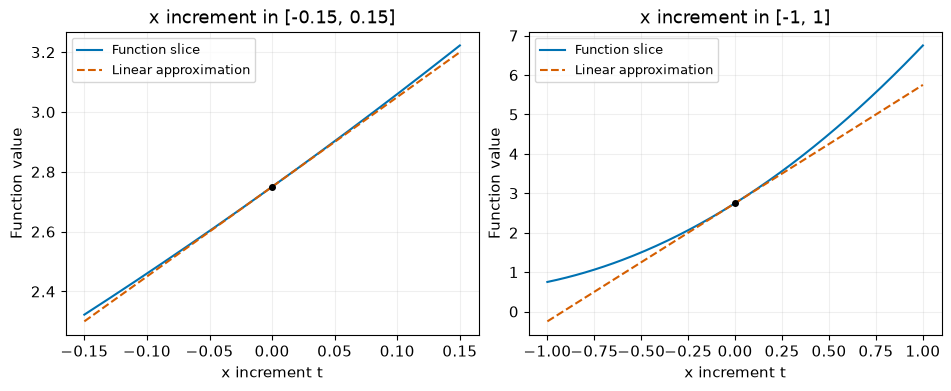

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.8), layout="constrained")
for ax, radius in zip(axes, [0.15, 1.0]):
    t = np.linspace(-radius, radius, 201)
    actual = f(p[0] + t, p[1])
    linear = f(*p) + gradient[0] * t
    ax.plot(t, actual, color="#0072B2", label="Function slice")
    ax.plot(t, linear, "--", color="#D55E00", label="Linear approximation")
    ax.plot(0, f(*p), "ko", markersize=4)
    ax.set(
        title=f"x increment in [-{radius:g}, {radius:g}]",
        xlabel="x increment t",
        ylabel="Function value",
    )
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9)
# 预期两图均在 t=0 相切；较大的横轴范围里，曲线高于直线的差距更明显。
plt.show()

## 5 偏导都存在，仍可能不可微

考察定义在整个平面上的函数

$$g(x,y)=\begin{cases}
\dfrac{xy}{\sqrt{x^2+y^2}},&(x,y)\ne(0,0),\\
0,&(x,y)=(0,0).
\end{cases}$$

沿坐标轴，$g(h,0)=g(0,h)=0$，因此 $g_x(0,0)=g_y(0,0)=0$。而且由 $2|xy|\le x^2+y^2$ 可知

$$|g(x,y)|\le\frac{\sqrt{x^2+y^2}}2\to0,$$

所以 g 在原点甚至连续。但如果它可微，线性部分只能是两个零偏导组成的零映射。沿 $(x,y)=(t,t)$、$t\ne0$，其归一化余项为

$$\frac{|g(t,t)|}{\|(t,t)^T\|_2}
=\frac{|t|/\sqrt2}{\sqrt2|t|}=\frac12.$$

这个比值不趋于零，故 g 在原点不可微。偏导存在加上函数连续仍不够；不能在这里把“偏导组成零向量”解释为对所有小增量都有效的零线性近似。

In [9]:
def g(x, y):
    """计算反例的标量函数值，原点单独定义。"""
    radius = np.sqrt(x**2 + y**2)
    if radius == 0:
        return 0.0
    return x * y / radius


for h in [0.1, 0.01, 0.001]:
    dx_quotient = (g(h, 0) - g(0, 0)) / h
    dy_quotient = (g(0, h) - g(0, 0)) / h
    normalized_remainder = abs(g(h, h)) / np.linalg.norm([h, h])
    # 每组轴向差商均为 0，但对角线归一化余项始终为 0.5。
    print(
        f"h={h:g}，两个轴向差商={dx_quotient:g}, {dy_quotient:g}，对角线归一化余项={normalized_remainder:g}"
    )
# 两个偏导差商恒为 0，归一化余项恒为 0.5；代数式解释了不可微。

h=0.1，两个轴向差商=0, 0，对角线归一化余项=0.5
h=0.01，两个轴向差商=0, 0，对角线归一化余项=0.5
h=0.001，两个轴向差商=0, 0，对角线归一化余项=0.5


## 6 方向导数先明确移动方向与长度

偏导只检查坐标轴方向。给定单位列向量 $u\in\mathbb R^n$，满足 $\|u\|_2=1$，本章的方向导数（directional derivative）定义为

$$D_u f(p)=\lim_{t\to0}\frac{f(p+tu)-f(p)}{t},$$

前提是极限存在。t 是沿所选方向的带符号距离。若最初给的是非零向量 v，应先用 $u=v/\|v\|_2$ 单位化；零向量没有可单位化的方向。

若 f 在 p 可微，把增量 $\mathbf{h}=tu$ 代入全微分，就得到

$$\frac{f(p+tu)-f(p)}t=\nabla f(p)^Tu+\frac{r(tu)}t
\longrightarrow\nabla f(p)^Tu.$$

余项条件保证最后一项趋于零，因此可微时 $D_uf(p)=\nabla f(p)^Tu$。这个推导说明为何不能只凭偏导存在就套用点积公式。

In [10]:
v = np.array([3.0, 4.0])
u = v / np.linalg.norm(v)
predicted = gradient @ u
print("单位方向：", u, "；长度：", np.linalg.norm(u))  # 预期约为 [0.6 0.8] ；长度： 1。
print("梯度点积：", predicted)  # 5.8。
for t in [1e-2, 1e-3, 1e-4]:
    quotient = (f(*(p + t * u)) - f(*p)) / t
    print(f"t={t:.0e}，方向差商={quotient:.6f}")  # 方向差商为 5.8324、5.80324、5.800324，靠近 5.8。
# 差商趋近 5.8；其偏差来自这个二次函数的余项。

单位方向： [0.6 0.8] ；长度： 1.0
梯度点积： 5.8
t=1e-02，方向差商=5.832400
t=1e-03，方向差商=5.803240
t=1e-04，方向差商=5.800324


如果直接沿 $p+tv$ 移动而不单位化，求到的是相对于参数 t 的变化率 $\nabla f(p)^Tv$。由于每单位 t 实际走了 $\|v\|_2$ 的距离，它等于单位方向变化率的 $\|v\|_2$ 倍。

有些资料也把非单位 v 对应的参数导数称为方向导数；本章统一使用单位方向定义，比较方向时保持移动长度相同。

In [11]:
print("未单位化的点积：", gradient @ v)  # 29。
print("单位方向变化率乘路径速度：", (gradient @ u) * np.linalg.norm(v))  # 29。
print("同一方向放大向量后的单位结果：", gradient @ (10 * v / np.linalg.norm(10 * v)))  # 预期约为 5.8。
# 仅改变向量长度，不应改变每单位距离的变化率。

未单位化的点积： 29.0
单位方向变化率乘路径速度： 29.0
同一方向放大向量后的单位结果： 5.8


### 6.1 最大一阶变化来自梯度方向

当 $\nabla f(p)\ne0$ 时，对任意单位方向 u，内积公式给出

$$D_uf(p)=\|\nabla f(p)\|_2\cos\theta,$$

其中 $\theta$ 是 u 与梯度的夹角。最大值为 $\|\nabla f(p)\|_2$，在 $u=\nabla f(p)/\|\nabla f(p)\|_2$ 时取得；反方向取得最小值。这是在当前点、按相同欧氏距离比较的一阶结论，不保证有限长度的移动始终具有相同比较结果。

当梯度为零且函数可微时，所有方向导数都为零，但函数仍可能有二阶等更高阶变化。本例在原点梯度为零，却不是常数函数。

In [12]:
unit_gradient = gradient / np.linalg.norm(gradient)
directions = {
    "x 正方向": np.array([1.0, 0.0]),
    "y 正方向": np.array([0.0, 1.0]),
    "梯度方向": unit_gradient,
    "负梯度方向": -unit_gradient,
}
for name, direction in directions.items():
    print(name, "方向导数：", gradient @ direction)  # 四个方向导数依次约为 3、5、5.83095、-5.83095。
# 梯度方向约为 5.83095，比两个坐标轴方向的 3、5 都大。
print("原点梯度：", gradient_f(0, 0))  # 预期为 [0 0]。
print("离开原点后仍可变化：", f(0.1, 0), f(0, 0.1))  # 0.01、0.03。

x 正方向 方向导数： 3.0
y 正方向 方向导数： 5.0
梯度方向 方向导数： 5.830951894845299
负梯度方向 方向导数： -5.830951894845299
原点梯度： [0 0]
离开原点后仍可变化： 0.010000000000000002 0.030000000000000006


## 7 等高线切向与梯度垂直

对连续可微函数，在 $\nabla f(p)\ne0$ 的点，经过 p 的等高线在局部有切线。沿等高线运动时函数值保持不变，因此切向量 w 满足 $\nabla f(p)^Tw=0$。

本例经过 $p=(1,0.5)^T$ 的等高线是 $f(x,y)=2.75$。梯度为 $(3,5)^T$，可以选单位切向量 $w=(-5,3)^T/\sqrt{34}$，其切线方程为

$$3(x-1)+5(y-0.5)=0.$$

“沿切向一阶变化为零”不等于“沿整条直线函数保持不变”。等高线通常是弯曲的，有限直线位移仍可能离开等高线。下图箭头都画成单位长度，只表示方向；梯度本身的长度约为 5.83，没有按原长度画出。

梯度与切向的点积： 0.0
沿切向走 0.2 后的实际变化： 0.025882352941176467


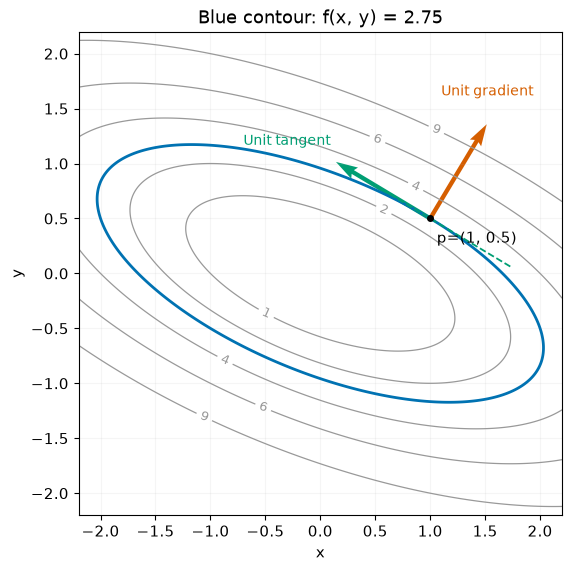

In [13]:
# 交换梯度分量并给一个分量反号，得到与梯度垂直的单位方向。
tangent = np.array([-gradient[1], gradient[0]]) / np.linalg.norm(gradient)
print("梯度与切向的点积：", gradient @ tangent)  # 接近 0。
print("沿切向走 0.2 后的实际变化：", f(*(p + 0.2 * tangent)) - f(*p))  # 预期约为 0.0258824。
# 方向导数为 0，但有限位移的变化约为 0.02588，并非恒为零。

coordinates = np.linspace(-2.2, 2.2, 351)
x_grid, y_grid = np.meshgrid(coordinates, coordinates)
fig, ax = plt.subplots(figsize=(6.8, 5.6), layout="constrained")
contours = ax.contour(
    x_grid,
    y_grid,
    f(x_grid, y_grid),
    levels=[1, 2, 4, 6, 9],
    colors="#999999",
    linewidths=0.9,
)
ax.clabel(contours, fmt="%g", fontsize=9)
# 单独加粗通过 p 的等高线，区别于背景中的其他函数值。
ax.contour(
    x_grid, y_grid, f(x_grid, y_grid), levels=[f(*p)], colors="#0072B2", linewidths=2
)
line_parameter = np.linspace(-0.85, 0.85, 2)
# 新增列轴后，起点和方向广播到两个端点，得到形状 (2, 2) 的切线坐标。
line = p[:, None] + tangent[:, None] * line_parameter
ax.plot(line[0], line[1], "--", color="#009E73", linewidth=1.3)
# 两支单位箭头都从 p 出发，分别显示梯度和切向方向。
for direction, color in [(unit_gradient, "#D55E00"), (tangent, "#009E73")]:
    ax.quiver(
        *p, *direction, angles="xy", scale_units="xy", scale=1, color=color, width=0.009
    )
ax.plot(*p, "ko", markersize=4)
ax.text(p[0] + 0.06, p[1] - 0.22, "p=(1, 0.5)")
ax.text(1.1, 1.62, "Unit gradient", color="#D55E00", fontsize=10)
ax.text(-0.7, 1.17, "Unit tangent", color="#009E73", fontsize=10)
ax.set(
    title="Blue contour: f(x, y) = 2.75",
    xlabel="x",
    ylabel="y",
    xlim=(-2.2, 2.2),
    ylim=(-2.2, 2.2),
)
ax.set_aspect("equal")
ax.grid(alpha=0.12)
# 预期梯度箭头与蓝色等高线的切线垂直，切向箭头沿切线指向。
plt.show()

## 8 综合应用：比较相同移动距离下的温度变化

用教学温度场

$$T(x,y)=20+x^2+2xy+3y^2$$

比较不同方向的移动。这里 x、y 的数值以米计，T 的数值以摄氏度计；系数按这些单位定义。它是人为指定的模型，不是实际测量数据。基准位置为 $p=(1,0.5)^T\,\mathrm{m}$，温度为 $22.75\,{}^\circ\mathrm C$，梯度为 $(3,5)^T\,{}^\circ\mathrm C/\mathrm m$。

对单位方向 u 和移动距离 $s\ge0$，一阶预测为

$$\Delta T\approx s\,\nabla T(p)^Tu.$$

比较 x 正方向、梯度方向和切向。三者必须使用同一个 s，才能把方向差异与移动距离分开。先对 $s=0.05\,\mathrm m$ 列出预测与实际变化，并用余项公式独立核对差值。

In [14]:
distance = 0.05
walking_directions = {
    "x direction": np.array([1.0, 0.0]),
    "gradient direction": unit_gradient,
    "tangent direction": tangent,
}
print("基准温度 (°C)：", 20 + f(*p))  # 预期约为 22.75。
for name, direction in walking_directions.items():
    delta = distance * direction
    prediction = gradient @ delta
    actual = f(*(p + delta)) - f(*p)  # 常数 20 在温度差中相消。
    exact_remainder = delta[0] ** 2 + 2 * delta[0] * delta[1] + 3 * delta[1] ** 2
    # 三方向的预测误差分别约为 0.0025、0.008382、0.001618 °C；切向预测为 0。
    print(
        f"{name}: 预测={prediction:.6f} °C，实际={actual:.6f} °C，差={actual - prediction:.6f} °C"
    )
    # 三次均为 True，差值与已推导余项相符。
    print(
        "  差值与余项一致：",
        np.isclose(actual - prediction, exact_remainder, atol=1e-12, rtol=0),
    )
# 梯度方向有最大的一阶增温；切向的一阶预测为 0，但实际变化仍有小余项。

基准温度 (°C)： 22.75
x direction: 预测=0.150000 °C，实际=0.152500 °C，差=0.002500 °C
  差值与余项一致： True
gradient direction: 预测=0.291548 °C，实际=0.299930 °C，差=0.008382 °C
  差值与余项一致： True
tangent direction: 预测=0.000000 °C，实际=0.001618 °C，差=0.001618 °C
  差值与余项一致： True


把移动距离扩大到 0.5 米，画出每条路径的实际温度变化与一阶预测。三幅图共用纵轴尺度；实线来自直接代入模型，虚线来自基准点处的全微分，二者都不包含传感器噪声或测量不确定性。

判断某个移动距离是否足够“小”，应比较近似误差与当前任务允许的误差，而不是只看距离的数值。这里可以直接求余项；一般函数需要另外评估近似误差。

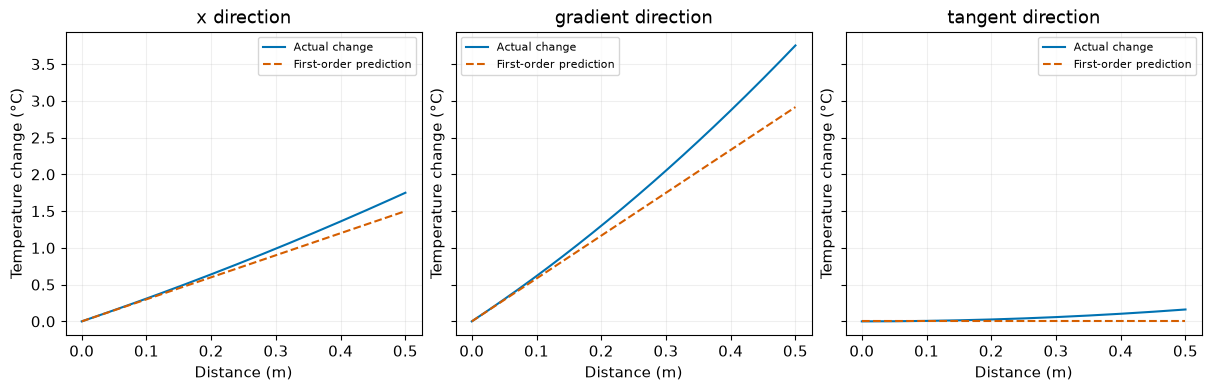

In [15]:
distances = np.linspace(0, 0.5, 151)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True, layout="constrained")
for ax, (name, direction) in zip(axes, walking_directions.items()):
    x_path = p[0] + distances * direction[0]
    y_path = p[1] + distances * direction[1]
    actual = f(x_path, y_path) - f(*p)
    predicted = distances * (gradient @ direction)
    ax.plot(distances, actual, color="#0072B2", label="Actual change")
    ax.plot(distances, predicted, "--", color="#D55E00", label="First-order prediction")
    ax.set(title=name, xlabel="Distance (m)", ylabel="Temperature change (°C)")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
# 预期梯度方向的初始上升最快；切向的一阶预测始终为 0，但实际温度变化仍向上弯曲。
plt.show()

## 本章小结

（1）偏导固定其他变量，只沿一个坐标方向求变化率；沿路径同时改变多个输入是另一个问题。

（2）梯度按输入顺序收集偏导，本章采用列布局。只有偏导存在，不能保证梯度给出所有方向的线性近似。

（3）可微要求实际变化减去全微分后，余项相对于增量长度趋于零，且对所有趋近方式成立。连续的一阶偏导是常用充分条件。

（4）可微时，单位方向导数等于梯度点积；比较不同方向必须保持单位长度。非零梯度指向最大一阶增长方向，并垂直于局部等高线。

（5）全微分预测的是局部一阶变化。梯度为零或沿切向运动时，高阶变化仍可能存在。

自查：能否解释连续反例为什么仍不可微？能否分清 df 与实际变化？能否说明未经单位化的向量会如何改变点积的含义？

## 练习

（1）对 $F(x,y)=x^2y+2y^2$，手算两个偏导及点 $(2,1)$ 处的列梯度。用中心差分核对，至少比较两个非零步长。然后沿 $x=y=t$ 写出 F 的单变量表达式，说明其导数为什么不能直接用一个偏导替代。

In [16]:
def exercise_f(x, y):
    return x**2 * y + 2 * y**2


exercise_point = np.array([2.0, 1.0])
# 补充手算梯度、两个步长的差分结果及误差。

（2）继续使用正文 f，在 $p=(1,0.5)^T$ 沿 $v=(-4,3)^T$ 的方向移动。先单位化，求每单位距离的方向导数，再预测移动 0.1 后的变化并直接代入核对。把 v 改为 10v，说明哪个数应保持不变，哪个参数导数会改变。

In [17]:
exercise_v = np.array([-4.0, 3.0])
exercise_distance = 0.1
# 补充单位方向、点积、实际变化及 10v 的对照。

（3）对正文反例 g，把“只沿两个坐标轴检查余项”的方法扩展到直线 $y=2x$。求 $|g(t,2t)|/\|(t,2t)^T\|_2$，先化简再选几个 t 核对。说明为什么轴向差商全部为零，仍不足以证明可微。

In [18]:
test_steps = [0.1, 0.01, 0.001]
# 沿 (t, 2t) 计算归一化余项，解释极限，不只报告数值接近与否。

（4）温度场模型要求一阶预测的绝对误差不超过 $0.01\,{}^\circ\mathrm C$。分别沿梯度方向与切向移动，利用余项表达式求满足要求的最大非负距离，并代入原式核对。解释为什么“切向的一阶变化为零”不表示任意距离都满足误差限制。

In [19]:
allowed_error = 0.01
# 沿固定单位方向 u，余项为 s² * (u[0]² + 2*u[0]*u[1] + 3*u[1]²)。
# 先解距离不等式，再用实际温度变化核对。

## 练习提示与解析

以下对应练习（1）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：求一个偏导时，把另一个自变量保持不变。

提示 2：沿 x=y=t 移动时，两个坐标都会变化，必须同时计入。

### 练习（1）参考解析

$F_x=2xy$，$F_y=x^2+4y$，在 $(2,1)$ 处的列梯度为 $(4,8)^T$。沿坐标方向分别作中心差分时，本题多项式会在精确算术下消去相应截断项；浮点结果仍可能有舍入差。

沿 $x=y=t$，函数变为 $t^3+2t^2$，导数为 $3t^2+4t$。链式法则也给出 $F_x(t,t)+F_y(t,t)=2t^2+(t^2+4t)$。单独一个偏导只描述另一个坐标固定时的变化，不能替代沿这条路径的导数。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| OpenStax：Calculus Volume 3 | [§4.1 Functions of Several Variables](https://openstax.org/books/calculus-volume-3/pages/4-1-functions-of-several-variables)，定义域、实值函数、曲面与 Level Curves；[§4.3 Partial Derivatives](https://openstax.org/books/calculus-volume-3/pages/4-3-partial-derivatives)，偏导极限与固定其他变量的计算；[§4.4 Tangent Planes and Linear Approximations](https://openstax.org/books/calculus-volume-3/pages/4-4-tangent-planes-and-linear-approximations)，式 (4.25)–(4.27)、Differentiability 余项定义、Theorems 4.6–4.7，以及原点连续但不可微的函数 xy/√(x²+y²)；[§4.6 Directional Derivatives and the Gradient](https://openstax.org/books/calculus-volume-3/pages/4-6-directional-derivatives-and-the-gradient)，式 (4.36)、(4.38)–(4.39)、单位化、最大变化率及梯度与等高线切向关系。 |
| MIT OpenCourseWare：18.013A 教材 | [§6.4 Derivatives in Two Dimensions](https://ocw.mit.edu/ans7870/18/18.013a/textbook/HTML/chapter06/section04.html)，沿直线的单变量变化与偏导；[§6.5 The Tangent Plane and the Gradient Vector](https://ocw.mit.edu/ans7870/18/18.013a/textbook/HTML/chapter06/section05.html)，切平面与局部线性近似；[§6.6 The Gradient and Directional Derivatives](https://ocw.mit.edu/ans7870/18/18.013a/textbook/HTML/chapter06/section06.html)，单位方向点积与多变量推广。 |
| SciPy 官方文档 | [differentiate.derivative](https://docs.scipy.org/doc/scipy/reference/generated/scipy.differentiate.derivative.html)，step_factor 与 Notes：有限差分步长、消减误差及浮点精度限制；本章手写小型差商作核对，不调用该 API。 |
| NumPy 官方文档 | NumPy 2.5：[linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html)，向量欧氏长度与单位化；[allclose](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html)，绝对和相对容差的比较条件。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contour.html)，网格和显式等高线；[Axes.quiver](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.quiver.html)，angles、scale_units、scale 的坐标含义。 |